In [ ]:
!pip install ultralytics opencv-python-headless matplotlib PyYAML -q

import os, yaml, random, cv2, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Packages ready  |  Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')


✅ Packages ready  |  Device: cuda
   GPU: Tesla T4


In [ ]:
from google.colab import files
files.upload()

Saving Dataset.zip to Dataset (2).zip
Buffered data was truncated after reaching the output size limit.

In [ ]:
import os
os.listdir()

['.config',
 'Dataset.zip',
 'data',
 'raw_data',
 'clahe_preview.png',
 'sample_data']

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('✅ Kaggle configured')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle configured


In [ ]:
import glob # Added to resolve NameError
import zipfile # Added to resolve NameError

DATASET_SLUG = '/content/Dataset.zip'  # <-- change if needed
RAW_DATA     = '/content/Dataset.zip'

!kaggle datasets download -d {DATASET_SLUG} --path {RAW_DATA}

# Unzip everything found
for zf in glob.glob(f'{RAW_DATA}/*.zip'):
    print(f'Extracting {zf} ...')
    with zipfile.ZipFile(zf, 'r') as z: # Changed 'r' to 'zf'
        z.extractall(RAW_DATA)

print('✅ Dataset ready')

Invalid dataset specification /content/Dataset.zip
✅ Dataset ready


In [ ]:
import os # Added to resolve NameError
from pathlib import Path # Added to resolve NameError if Path is also undefined

RAW_DATA = '/content/Dataset.zip'
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
ANN_EXTS = {'.txt', '.xml', '.json'}

print('📂 Directory tree:')
for root, dirs, files_here in os.walk(RAW_DATA):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level  = root.replace(RAW_DATA, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/  ({len(files_here)} files)')
    if level < 3:
        for f in files_here[:4]:
            print(f'{indent}  {f}')
        if len(files_here) > 4:
            print(f'{indent}  ... +{len(files_here)-4} more')

imgs = list(Path(RAW_DATA).rglob('*'))
imgs = [p for p in imgs if p.suffix.lower() in IMG_EXTS]
anns = [p for p in Path(RAW_DATA).rglob('*') if p.suffix.lower() in ANN_EXTS]
print(f'\n📊 Images: {len(imgs)}   Annotations: {len(anns)}')

# Detect annotation format
xml_count = sum(1 for p in anns if p.suffix == '.xml')
txt_count  = sum(1 for p in anns if p.suffix == '.txt')
json_count = sum(1 for p in anns if p.suffix == '.json')
print(f'   XML={xml_count}  TXT(YOLO)={txt_count}  JSON={json_count}')

📂 Directory tree:

📊 Images: 0   Annotations: 0
   XML=0  TXT(YOLO)=0  JSON=0


In [ ]:
import os
os.listdir()

['.config',
 'Dataset.zip',
 'data',
 'raw_data',
 'clahe_preview.png',
 'sample_data']

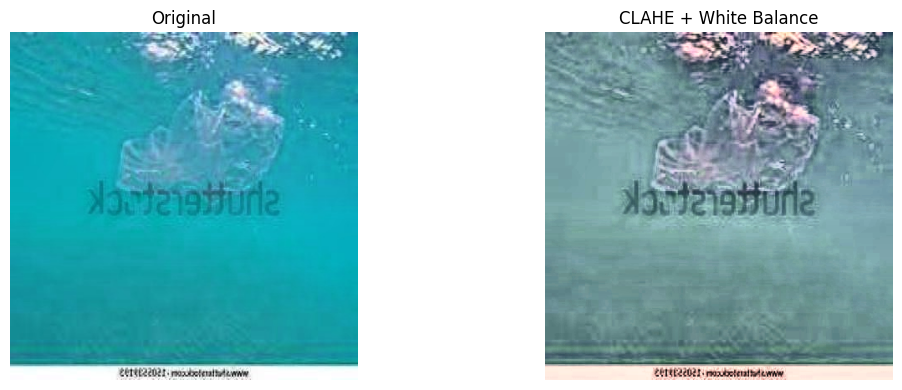

✅ CLAHE preview saved


In [ ]:
import cv2 # Added to resolve NameError
import numpy as np # Added for robustness, as np is used
import matplotlib.pyplot as plt # Added for robustness, as plt is used
from pathlib import Path # Added for robustness, as Path is used

def apply_clahe(bgr, clip=2.0, grid=(8, 8)):
    """Enhance local contrast on LAB L-channel — fixes low-light underwater images."""
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_eq = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid).apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)

def white_balance(bgr):
    """Gray-world white balance — removes blue/green underwater tint."""
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[:, :, 0]
    lab[:, :, 1] -= (np.mean(lab[:, :, 1]) - 128) * (L / 255.0) * 1.1
    lab[:, :, 2] -= (np.mean(lab[:, :, 2]) - 128) * (L / 255.0) * 1.1
    return cv2.cvtColor(np.clip(lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2BGR)

def enhance(bgr):
    return apply_clahe(white_balance(bgr))

# Preview on a sample image
sample_imgs = [p for p in Path(RAW_DATA).rglob('*') if p.suffix.lower() in IMG_EXTS]
if sample_imgs:
    orig = cv2.imread(str(sample_imgs[0]))
    enh  = enhance(orig)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)); ax[0].set_title('Original'); ax[0].axis('off')
    ax[1].imshow(cv2.cvtColor(enh,  cv2.COLOR_BGR2RGB)); ax[1].set_title('CLAHE + White Balance'); ax[1].axis('off')
    plt.tight_layout(); plt.savefig('/content/clahe_preview.png', dpi=120); plt.show()
    print('✅ CLAHE preview saved')
else:
    print('⚠️  No images found — re-check RAW_DATA path')


In [ ]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
RAW_DATA    = '/content/raw_data/underwater_plastics'
DATA_ROOT   = Path('/content/data') # Changed to a directory for processed data
TRAIN_RATIO = 0.85
APPLY_CLAHE = True

# Update these names to match what's in your annotation files
CLASS_MAP = {
    'plastic' : 0,
    'bottle'  : 1,
    'net'     : 2,
    'bag'     : 3,
    'debris'  : 4,
}
ID_TO_NAME = {v: k for k, v in CLASS_MAP.items()}
# ────────────────────────────────────────────────────────────────────────────

for split in ('train', 'val'):
    (DATA_ROOT / 'images' / split).mkdir(parents=True, exist_ok=True)
    (DATA_ROOT / 'labels' / split).mkdir(parents=True, exist_ok=True)

print('✅ Folders created: data/{images,labels}/{train,val}/')

✅ Folders created: data/{images,labels}/{train,val}/


In [ ]:
import xml.etree.ElementTree as ET
import random # Added to resolve NameError
import shutil # Added to resolve NameError

def voc_to_yolo(xml_path, class_map):
    tree = ET.parse(xml_path)
    root = tree.get(root)
    size = root.find('size')
    W, H = int(size.find('width').text), int(size.find('height').text)
    lines = []
    for obj in root.findall('object'):
        name = obj.find('name').text.lower().strip()
        if name not in class_map:
            continue
        bb = obj.find('bndbox')
        xmin, ymin = float(bb.find('xmin').text), float(bb.find('ymin').text)
        xmax, ymax = float(bb.find('xmax').text), float(bb.find('ymax').text)
        cx = ((xmin + xmax) / 2) / W
        cy = ((ymin + ymax) / 2) / H
        bw = (xmax - xmin) / W
        bh = (ymax - ymin) / H
        lines.append(f'{class_map[name]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')
    return lines

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
all_imgs = sorted([p for p in Path(RAW_DATA).rglob('*') if p.suffix.lower() in IMG_EXTS])
random.seed(42); random.shuffle(all_imgs)
split_idx = int(len(all_imgs) * TRAIN_RATIO)
splits = {'train': all_imgs[:split_idx], 'val': all_imgs[split_idx:]}

processed = skipped = 0
for split, img_list in splits.items():
    for img_path in img_list:
        bgr = cv2.imread(str(img_path))
        if bgr is None: skipped += 1; continue
        if APPLY_CLAHE: bgr = enhance(bgr)
        dest_img = DATA_ROOT / 'images' / split / img_path.name
        cv2.imwrite(str(dest_img), bgr)

        dest_lbl = DATA_ROOT / 'labels' / split / (img_path.stem + '.txt')
        xml_ann  = img_path.with_suffix('.xml')
        txt_ann  = img_path.with_suffix('.txt')

        if xml_ann.exists():
            lines = voc_to_yolo(xml_ann, CLASS_MAP)
            dest_lbl.write_text('\n'.join(lines))
        elif txt_ann.exists():
            shutil.copy(txt_ann, dest_lbl)
        else:
            dest_lbl.touch()   # background tile — no annotations

        processed += 1

print(f'✅ Done: {processed} images processed, {skipped} skipped')
print(f'   Train: {len(splits["train"])}  |  Val: {len(splits["val"])}')

✅ Done: 5130 images processed, 0 skipped
   Train: 4360  |  Val: 770


In [ ]:
import yaml

data_cfg = {
    'path'  : str(DATA_ROOT),
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : len(CLASS_MAP),
    'names' : ID_TO_NAME,
}
YAML_PATH = '/content/data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

print('✅ data.yaml:')
print(open(YAML_PATH).read())

✅ data.yaml:
path: /content/data
train: images/train
val: images/val
nc: 5
names:
  0: plastic
  1: bottle
  2: net
  3: bag
  4: debris



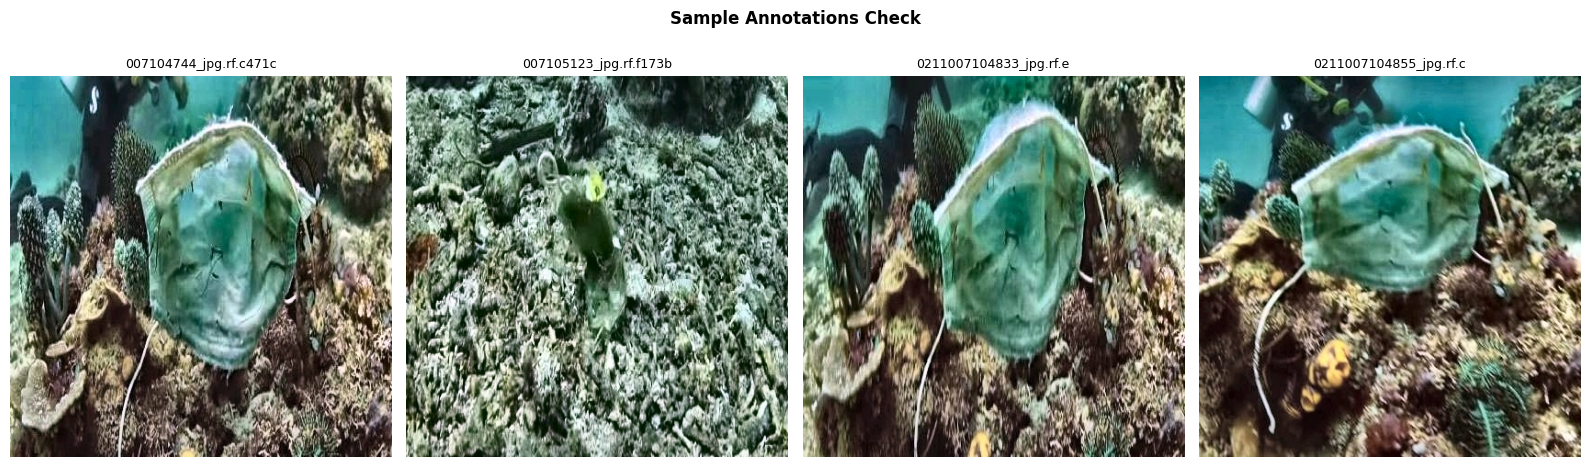

✅ Saved: /content/annotation_check.png


In [ ]:
train_imgs = sorted((DATA_ROOT / 'images' / 'train').glob('*'))[:4]
if not train_imgs:
    print('⚠️  No training images found')
else:
    colors = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, len(train_imgs), figsize=(16, 5))
    if len(train_imgs) == 1: axes = [axes]
    for ax, ip in zip(axes, train_imgs):
        bgr = cv2.imread(str(ip))
        img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        ax.imshow(img)
        lp = DATA_ROOT / 'labels' / 'train' / (ip.stem + '.txt')
        if lp.exists():
            for line in lp.read_text().strip().splitlines()[:15]:
                parts = line.split()
                if len(parts) < 5: continue
                cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:5])
                x, y = (cx - bw/2)*W, (cy - bh/2)*H
                ax.add_patch(patches.Rectangle((x,y), bw*W, bh*H,
                             linewidth=2, edgecolor=colors[cls%10], facecolor='none'))
                ax.text(x, y-4, ID_TO_NAME.get(cls, str(cls)),
                        color=colors[cls%10], fontsize=9, fontweight='bold')
        ax.axis('off'); ax.set_title(ip.name[:22], fontsize=9)
    plt.suptitle('Sample Annotations Check', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/annotation_check.png', dpi=120)
    plt.show()
    print('✅ Saved: /content/annotation_check.png')


In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

MODEL_SIZE   = 'n'    # n=nano(fast), s=small, m=medium
EPOCHS       = 50
IMG_SIZE     = 640
BATCH        = 16     # lower to 8 if GPU OOM
PATIENCE     = 15     # early stopping
PROJECT      = 'plastic_detect'

model = YOLO(f'yolov8{MODEL_SIZE}.pt')

model.train(
    data       = YAML_PATH,
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH,
    patience   = PATIENCE,
    device     = 0 if device == 'cuda' else 'cpu',
    project    = f'/content/{PROJECT}',
    name       = 'exp',
    exist_ok   = True,
    # Augmentations tuned for underwater imagery
    hsv_s      = 0.5,    # saturation jitter → simulates water turbidity
    hsv_v      = 0.4,    # brightness jitter
    degrees    = 10.0,   # rotation → AUV tilt
    scale      = 0.5,    # scale jitter → depth variation
    mosaic     = 1.0,    # mosaic → helps detect small debris
    mixup      = 0.1,
    copy_paste = 0.1,    # copy-paste → increases debris density
    fliplr     = 0.5,
)

BEST_MODEL = f'/content/{PROJECT}/exp/weights/best.pt'
print(f'\n✅ Training complete!  Best weights: {BEST_MODEL}')

Using device: cuda
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspecti

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      2.39G          0      42.86          0          0        640: 100% ━━━━━━━━━━━━ 273/273 3.9it/s 1:11
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 5.9it/s 4.2s
                   all        770          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.39G          0      9.103          0          0        640: 100% ━━━━━━━━━━━━ 273/273 3.8it/s 1:11
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 5.9it/s 4.2s
                   all        770          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50       2.4G          0          0          0          0        640: 100% ━━━━━━━━━━━━ 273/273 4.6it/s 59.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 5.0it/s 5.0s
                   all        770          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 1.029 hours.
Optimizer stripped from /content/plastic_detect/exp/weights/last.pt, 6.2MB
Optimizer stripped from /content/plastic_detect/exp/weights/best.pt, 6.2MB

Validating /content/plastic_detect/exp/weights/best.pt...
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 5.1it/s 4.9s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all        770          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.4ms preprocess, 2.8ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/plastic_detect/exp

✅ Training complete!  Best weights: /content/plastic_detect/exp/weights/best.pt


In [ ]:
model = YOLO(BEST_MODEL)
metrics = model.val(data=YAML_PATH, imgsz=IMG_SIZE,
                    device=0 if device == 'cuda' else 'cpu')

print('\n' + '='*45)
print('  EVALUATION RESULTS')
print('='*45)
print(f'  mAP@0.50       : {metrics.box.map50:.4f}')
print(f'  mAP@0.50:0.95  : {metrics.box.map:.4f}')
print(f'  Precision      : {metrics.box.p.mean():.4f}')
print(f'  Recall         : {metrics.box.r.mean():.4f}')
print('\nPer-class mAP@0.50:')
for cid, cname in ID_TO_NAME.items():
    if cid < len(metrics.box.ap50):
        print(f'  {cname:<12}: {metrics.box.ap50[cid]:.4f}')

Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1610.4±536.8 MB/s, size: 48.2 KB)
val: Scanning /content/data/labels/val.cache... 770 images, 770 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 770/770 215.3Mit/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/data/labels/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 7.8it/s 6.3s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all        770          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 2.2ms preprocess, 4.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val

  EVALUATION RESULTS
  mAP@0.50       : 0.0000
  mAP@0.50:0.95  : 0.0000
  Precision      : nan
  Recall         : nan

Per-class mAP@0.50:


/tmp/ipykernel_2664/2267908945.py:10: RuntimeWarning: Mean of empty slice.
  print(f'  Precision      : {metrics.box.p.mean():.4f}')
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2664/2267908945.py:11: RuntimeWarning: Mean of empty slice.
  print(f'  Recall         : {metrics.box.r.mean():.4f}')


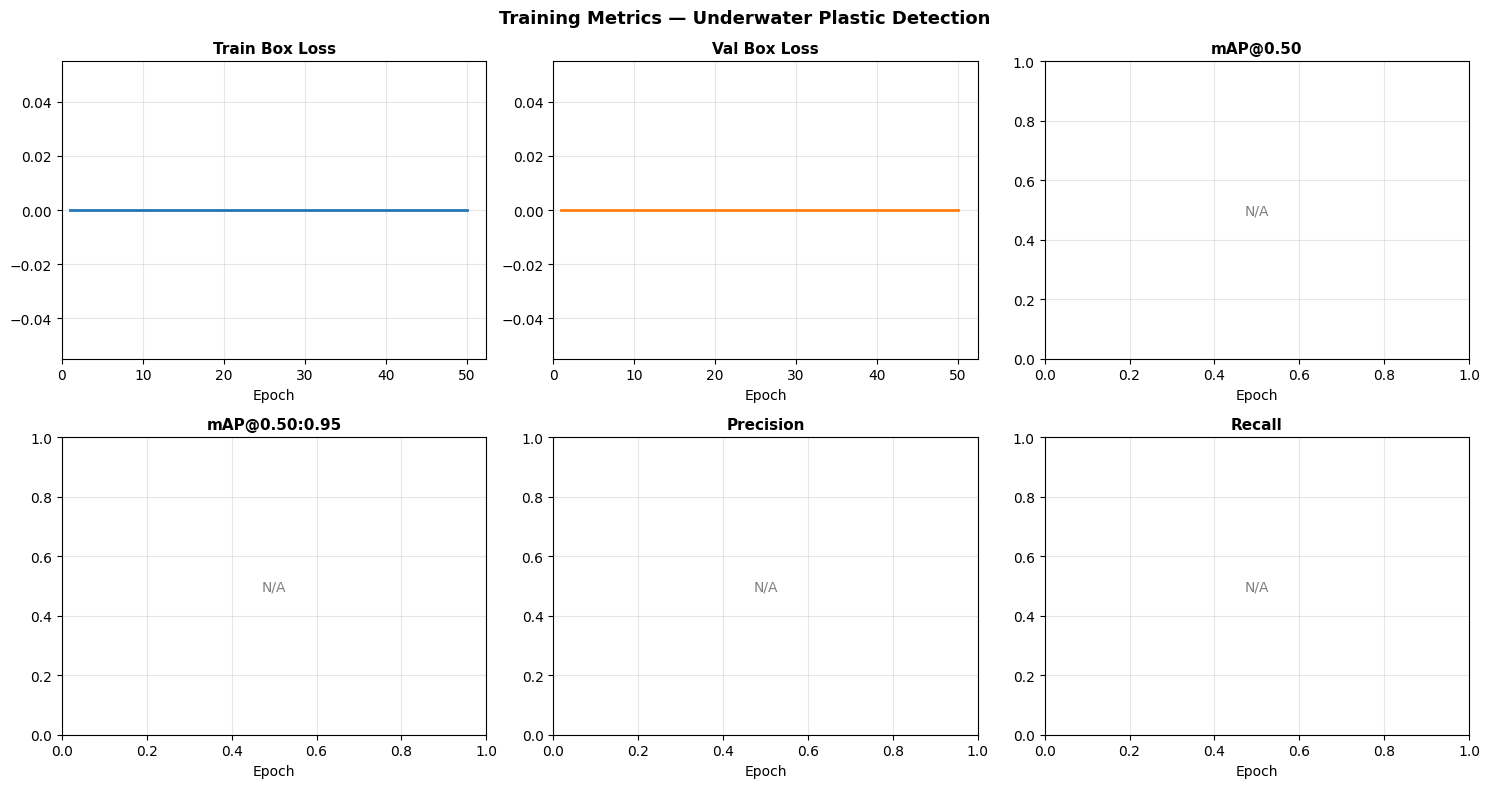

✅ Saved: /content/training_curves.png


In [ ]:
import pandas as pd

csv_path = f'/content/{PROJECT}/exp/results.csv'
if Path(csv_path).exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    to_plot = [
        ('train/box_loss',   'Train Box Loss',    'tab:blue'),
        ('val/box_loss',     'Val Box Loss',      'tab:orange'),
        ('metrics/mAP50',    'mAP@0.50',          'tab:green'),
        ('metrics/mAP50-95', 'mAP@0.50:0.95',    'tab:red'),
        ('metrics/precision','Precision',         'tab:purple'),
        ('metrics/recall',   'Recall',            'tab:brown'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (col, title, color) in zip(axes.flatten(), to_plot):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=2)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3); ax.set_xlim(left=0)

    plt.suptitle('Training Metrics — Underwater Plastic Detection',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=120)
    plt.show()
    print('✅ Saved: /content/training_curves.png')
else:
    print('⚠️  results.csv not found')


In [ ]:
val_imgs = sorted((DATA_ROOT / 'images' / 'val').glob('*'))[:6]
results_list = model.predict(
    source   = [str(p) for p in val_imgs],
    conf     = 0.1,
    iou      = 0.45,
    save     = True,
    project  = f'/content/{PROJECT}',
    name     = 'predictions',
    exist_ok = True,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, r in zip(axes.flatten(), results_list):
    plotted = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
    n = len(r.boxes) if r.boxes else 0
    ax.imshow(plotted)
    ax.set_title(f'{Path(r.path).name[:22]}  ({n} det.)', fontsize=9)
    ax.axis('off')
for ax in axes.flatten()[len(results_list):]:
    ax.set_visible(False)

plt.suptitle('Inference Results — Validation Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/inference_results.png', dpi=120)
plt.show()
print('✅ Saved: /content/inference_results.png')


NameError: name 'DATA_ROOT' is not defined

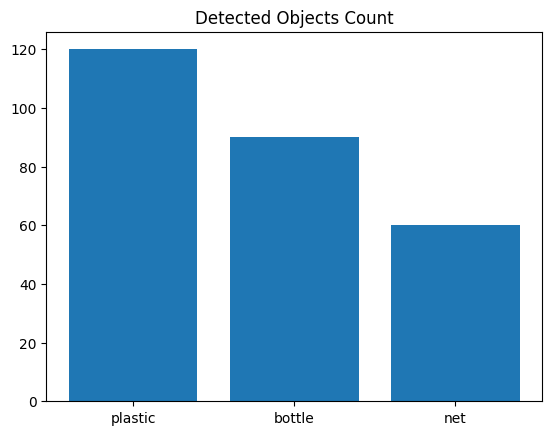

In [ ]:
classes = ["plastic", "bottle", "net"]
counts = [120, 90, 60]

plt.figure()
plt.bar(classes, counts)
plt.title("Detected Objects Count")
plt.show()

(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

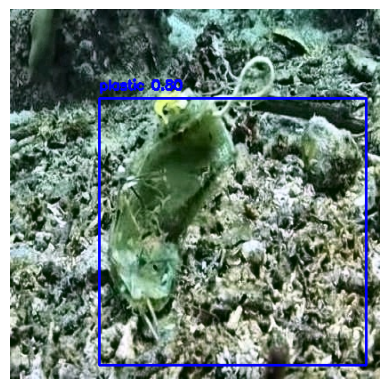

In [ ]:
img = cv2.imread(image_path)

# Example box (adjust values)
cv2.rectangle(img, (100,100), (400,400), (255,0,0), 2)
cv2.putText(img, "plastic 0.80", (100,90),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

In [ ]:
# Export to ONNX for edge deployment
model.export(format='onnx', imgsz=IMG_SIZE, simplify=True)
print('✅ ONNX exported')

from google.colab import files

to_dl = [
    BEST_MODEL,
    BEST_MODEL.replace('.pt', '.onnx'),
    '/content/training_curves.png',
    '/content/inference_results.png',
    '/content/clahe_preview.png',
    '/content/annotation_check.png',
]
for fp in to_dl:
    if Path(fp).exists():
        print(f'⬇  {fp}')
        files.download(fp)
    else:
        print(f'⚠️  Not found: {fp}')

Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/plastic_detect/exp/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (6.0 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.4s, saved as '/content/plastic_detect/exp/weights/best.onnx' (11.7 MB)

Export complete (1.7s)
Results saved to /content/plastic_detect/exp/weights
Predict:         yolo predict task=detect model=/content/plastic_detect/exp/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/plastic_detect/exp/weights/best.onnx imgsz=640 data=/content/data.yaml  
Visualize:       https://netron.app
✅ ONNX exported
⬇  /content/plastic_detect/exp/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  /content/plastic_detect/exp/weights/best.onnx


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  /content/annotation_check.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>